## Import necessary packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

## 1. Define the device (either CPU or GPU)
<span style="font-size: 1.5em; margin-right: 6px;">❗</span> We highly recommend GPU inference as the speedup could be many orders of magnitude

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## 2. Load the data

### We need the undersampled IR / PD *k*-space, undersampling mask, and coil sensitivity maps as input to the PSIRNet

Let b, nc, ro, pe denote the batch size, number of coils, readout, and phase encode dimensions, respectively.

The variables are expected in following data types and shapes: 

- ```ir_kspace```: torch.cfloat of shape ```(b, nc, ro, pe)``` 
- ```pd_kspace```: torch.cfloat of shape ```(b, nc, ro, pe)```
- ```mask```: torch.bool of shape ```(b, 1, ro, pe)```
- ```sens_maps```: torch.cfloat of shape ```(b, nc, ro, pe)``` 

<span style="font-size: 1.5em; margin-right: 6px;">⚠️</span> Please fill the ```phantom_path``` with the path of **phantom.npz**

In [ ]:
phantom_path = # Path to the phantom.npz file
phantom = np.load(phantom_path)
ir_kspace = torch.from_numpy(phantom['ir_kspace']).to(device)
pd_kspace = torch.from_numpy(phantom['pd_kspace']).to(device)
mask = torch.from_numpy(phantom['mask']).to(device)
sens_maps = torch.from_numpy(phantom['sens_maps']).to(device)
moco_psir = phantom['moco_psir']  # Reference standard MOCO PSIR image

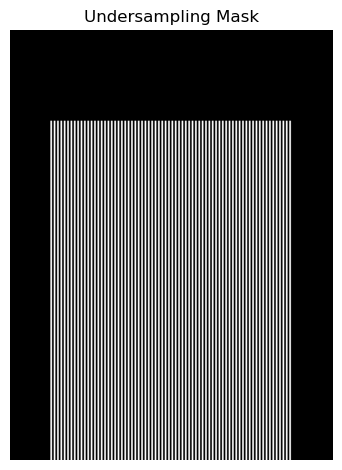

In [4]:
# Illustrate the undersampling mask
plt.imshow(mask[0, 0].cpu(), cmap='gray')
plt.axis('off')
plt.title(r'Undersampling Mask')
plt.tight_layout()
plt.show()

## 2. Load the model weights 

<span style="font-size: 1.5em; margin-right: 6px;">⚠️</span> Please fill the ```checkpoint_path``` with the path of **PSIRNet.pt**

In [ ]:
checkpoint_path = # Path to the PSIRNet checkpoint
model = torch.jit.load(checkpoint_path, map_location=device)

## 3. Perform inference and visualize the reconstruction

### Inference

In [6]:
with torch.inference_mode():
    psir_recon = model(ir_kspace, pd_kspace, mask, sens_maps)

### Visualize the reconstructed PSIR image and compare it with the MOCO PSIR

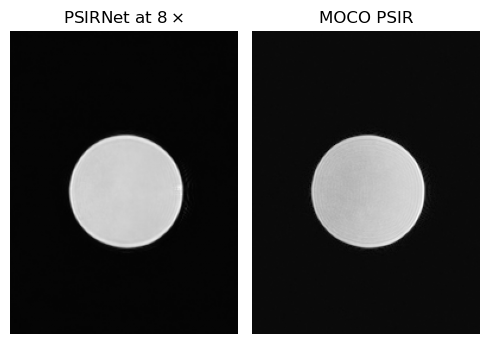

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(5, 4))

# Plot the reconstructed PSIR image
axes[0].imshow(psir_recon[0, 0].cpu(), cmap='gray')
axes[0].axis('off')
axes[0].set_title(r'PSIRNet at $8\times$')

# Plot the MOCO PSIR image
axes[1].imshow(moco_psir, cmap='gray')
axes[1].axis('off')
axes[1].set_title('MOCO PSIR')

plt.tight_layout()
plt.show()